# AppVision Analytics · Launch Readiness Study
## 05 · Out-of-time check: what actually happened

**Brief question answered here:**
- *The model learned from a 2021 snapshot. Does it still hold for apps launching years later?*

**Approach:** Notebook 03 tested the Launch Outlook on unseen developers, but every app in that test was observed at the same moment as the training data. That can't show whether the store has changed since. Took a sample of apps that were **1–12 months old in June 2021**, re-checked each one's Google Play listing in **October 2026**, and compared where they actually ended up with what the model would have forecast in 2021 from launch-time inputs alone.

This is the closest available stand-in for "launch now, check back in five years". It tests two things at once: the model, and the assumption behind it that an app *X* days old today will look like apps that were *X* days old in 2021.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from appvision import bands, features, names
from appvision.outlook import LaunchOutlook
from appvision.style import use_notebook_style, BLUE, ORANGE, INK_2, MUTED, AXIS, BAND_COLORS

use_notebook_style()
DATA = REPO / "data" / "v2"
ARTIFACTS = REPO / "artifacts"
SNAPSHOT = pd.Timestamp("2021-06-16")
SEED = 42

### 1 · Re-checked a stratified sample on the live store
`scripts/rescrape_sample.py` drew **1,000 apps from each 2021 install band** among apps that were 30–365 days old at the snapshot (equal counts, so the rare 100K+ bands had enough apps to measure). It then looked up each listing one at a time with a pause between requests, and stored only public listing fields: still live or removed, and the current install count. The install count is the same exact figure (*Maximum Installs*) the 2021 bands were built from, so 2021 and 2026 are directly comparable.

In [2]:
check = pd.read_parquet(DATA / "rescrape_sample.parquet")
check["checked_at"] = pd.to_datetime(check["checked_at"], utc=True).dt.tz_localize(None)

cols = ["app_id", "app_name", "developer_id", "category", "content_rating", "free", "price_usd", "ad_supported",
        "in_app_purchases", "size_mb", "size_varies", "min_android", "min_android_varies", "has_website",
        "has_privacy", "dev_prior_apps", "dev_prior_log_installs", "name_words", "age_days", "installs", "band", "in_model"]
apps = pd.read_parquet(DATA / "apps_2021.parquet", columns=cols)
apps = apps[(apps["in_model"] == 1) & apps["age_days"].between(30, 2200)].drop(columns="in_model").reset_index(drop=True)

# Rebuilt notebook 03's developer split exactly, to tell apart apps whose developer the model never saw
dev = pd.factorize(apps["developer_id"])[0]
_, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=SEED).split(apps, groups=dev))
apps["unseen_dev"] = False
apps.loc[te, "unseen_dev"] = True

# Population the sample was drawn from, per 2021 band, for re-weighting
young = apps[apps["age_days"].between(30, 365)]
pool = young.groupby(["unseen_dev", "band"]).size()

df = check.merge(apps.drop(columns="developer_id"), on="app_id", how="left", validate="one_to_one")
assert df["band"].notna().all()
del apps, young, dev, te
df["live"] = df["status"].eq("live")
df["band_2026"] = np.where(df["live"], bands.band_of(df["installs_now"].fillna(0)), -1)
df["age_now"] = df["age_days"] + (df["checked_at"] - SNAPSHOT).dt.days
print(f"{len(df):,} apps re-checked between {df['checked_at'].min():%d %b %Y} and {df['checked_at'].max():%d %b %Y}")
print(f"Age at re-check: {df['age_now'].min():,.0f}–{df['age_now'].max():,.0f} days "
      f"({df['age_now'].min() / 365.25:.1f}–{df['age_now'].max() / 365.25:.1f} years)")
print(f"From developers the model never saw: {df['unseen_dev'].sum():,}")

5,000 apps re-checked between 06 Oct 2026 and 06 Oct 2026
Age at re-check: 1,968–2,303 days (5.4–6.3 years)
From developers the model never saw: 942


Each sampled app stands for a different number of real apps: one under-1K app represents several hundred, one 1M+ app only a couple. Every rate below is weighted back to the real mix of the store, so headline numbers describe the store and not the sample design.

In [3]:
n_sampled = df.groupby(["unseen_dev", "band"]).size()
df["weight"] = [pool[(u, b)] / n_sampled[(u, b)] for u, b in zip(df["unseen_dev"], df["band"])]

survival = (df.assign(removed=~df["live"])
              .groupby("band")
              .agg(apps=("app_id", "size"), removed=("removed", "mean"), median_installs_2021=("installs", "median")))
survival.index = bands.BAND_LABELS
store_removed = np.average(~df["live"], weights=df["weight"])
print(f"Removed from Google Play since 2021 (store-weighted): {store_removed:.1%}")
survival.style.format({"removed": "{:.1%}", "median_installs_2021": "{:,.0f}"})

Removed from Google Play since 2021 (store-weighted): 81.2%


,apps,removed,median_installs_2021
Under 1K,1000,82.7%,60
1K–10K,1000,79.8%,"2,712"
10K–100K,1000,78.3%,"23,724"
100K–1M,1000,69.7%,"202,756"
1M+,1000,46.0%,"2,192,230"


### 2 · Where apps went between year one and year five
For apps still live, compared each one's 2021 band with its 2026 band. This shows how much of an app's fate is already visible in its first year, before looking at the model at all.

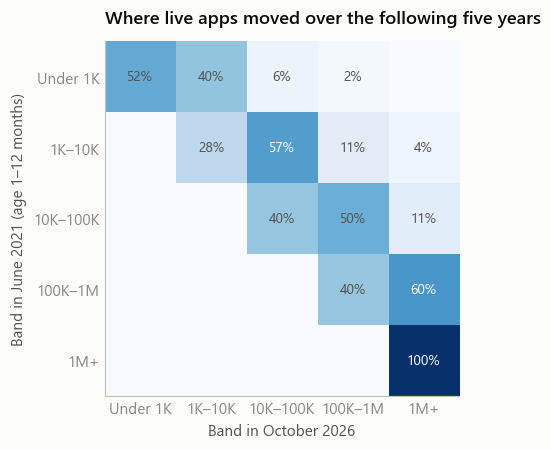

Moved up at least one band: 54.1% · stayed: 45.9% · fell: 0.0%


In [4]:
live = df[df["live"]].copy()
moves = pd.crosstab(live["band"], live["band_2026"], values=live["weight"], aggfunc="sum", normalize="index") \
          .reindex(index=range(5), columns=range(5), fill_value=0)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.imshow(moves.to_numpy(), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        v = moves.iat[i, j]
        if v >= 0.005:
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9, color="white" if v > 0.55 else INK_2)
ax.set_xticks(range(5), bands.BAND_LABELS)
ax.set_yticks(range(5), bands.BAND_LABELS)
ax.set_xlabel("Band in October 2026")
ax.set_ylabel("Band in June 2021 (age 1–12 months)")
ax.grid(False)
ax.set_title("Where live apps moved over the following five years")
plt.tight_layout()
plt.show()

moved_up = np.average(live["band_2026"] > live["band"], weights=live["weight"])
fell = np.average(live["band_2026"] < live["band"], weights=live["weight"])
print(f"Moved up at least one band: {moved_up:.1%} · stayed: {1 - moved_up - fell:.1%} · fell: {fell:.1%}")

### 3 · Scored every app as the model would have in 2021
Built each app's launch-time inputs exactly as the app does, using only what was known in June 2021. Set **time on the store to the app's actual age at the re-check**, since that is the horizon being forecast. A few apps were a little past the model's 6-year training range, so their age was capped at 2,200 days.

The comparison is the **category + age** baseline from notebook 03: the 2021 mix of outcomes for apps of the same category and age. Beating it means the launch-time inputs add something beyond "look up your category".

In [5]:
outlook = LaunchOutlook(ARTIFACTS)
X = df.copy()
X["name_signal"] = names.name_signal(X["app_name"].astype(str).tolist(), outlook.idf, outlook.coef, outlook.intercept)
X["age_days"] = X["age_now"].clip(upper=2200)
p_model = outlook.booster.predict(xgb.DMatrix(features.to_model_frame(X), enable_categorical=True))
p_base = np.vstack([outlook.typical(c, a) for c, a in zip(df["category"].astype(str), X["age_days"])])

for name, p in [("model", p_model), ("base", p_base)]:
    odds = bands.reach_odds(p)
    df[f"{name}_band"] = p.argmax(1)
    for k, t in enumerate(bands.THRESHOLD_LABELS):
        df[f"{name}_{t}"] = odds[:, k]
df.loc[df["live"], ["model_band", "base_band", "band_2026"]].head()

,model_band,base_band,band_2026
2,0,0,0
5,0,1,0
6,0,0,1
12,2,0,1
18,0,0,0


### 4 · Scored the forecasts against what happened
Measured two ways, both weighted to the store:
- **Live apps only:** apps still on Google Play in 2026, scored against their actual 2026 band.
- **Every app, removed ones at their 2021 band:** removed apps have no 2026 count, but their installs can't have been lower than in 2021, and an app that was pulled almost certainly stopped growing. Counting them at their 2021 band avoids judging the model only on survivors.

The headline set is apps from **developers the model never saw**, the same rule as notebook 03. The 95% ranges come from 1,000 bootstrap resamples drawn within each 2021 band, so they show how much the numbers could move with a different sample.

In [6]:
df["band_final"] = np.where(df["live"], df["band_2026"], df["band"])


def scores(d, prefix, target="band_2026"):
    y, w = d[target].to_numpy(), d["weight"].to_numpy()
    pred = d[f"{prefix}_band"].to_numpy()
    out = {
        "accuracy": accuracy_score(y, pred, sample_weight=w),
        "within_one": float(np.average(np.abs(pred - y) <= 1, weights=w)),
    }
    for k, t in [(1, "10K+"), (2, "100K+")]:
        hit = y >= k + 1
        out[f"auc_{t}"] = roc_auc_score(hit, d[f"{prefix}_{t}"], sample_weight=w) if 0 < hit.sum() < len(hit) else np.nan
    return out


def bootstrap(d, prefix, target, n=1000, seed=0):
    rng = np.random.default_rng(seed)
    groups = [g.index.to_numpy() for _, g in d.groupby("band")]
    draws = []
    for _ in range(n):
        idx = np.concatenate([rng.choice(g, len(g)) for g in groups])
        draws.append(scores(d.loc[idx], prefix, target))
    draws = pd.DataFrame(draws)
    return draws.quantile(0.025), draws.quantile(0.975)


meta = json.loads((ARTIFACTS / "outlook_meta.json").read_text(encoding="utf-8"))
m03 = meta["metrics"]["model"]

rows = {}
for label, subset, target in [
    ("Unseen developers · live apps", df["live"] & df["unseen_dev"], "band_2026"),
    ("Unseen developers · every app", df["unseen_dev"], "band_final"),
    ("All sampled · live apps", df["live"], "band_2026"),
    ("All sampled · every app", pd.Series(True, index=df.index), "band_final"),
]:
    d = df[subset].reset_index(drop=True)
    for prefix, who in [("model", "Launch Outlook"), ("base", "Category + age")]:
        est = scores(d, prefix, target)
        lo, hi = bootstrap(d, prefix, target)
        rows[(label, who)] = {k: f"{est[k]:.1%} ({lo[k]:.0%}–{hi[k]:.0%})" if "auc" not in k
                              else f"{est[k]:.2f} ({lo[k]:.2f}–{hi[k]:.2f})" for k in est}
rows[("2021 test (notebook 03)", "Launch Outlook")] = {
    "accuracy": f"{m03['accuracy']:.1%}", "within_one": f"{m03['within_one']:.1%}",
    "auc_10K+": f"{m03['auc_10k']:.2f}", "auc_100K+": f"{m03['auc_100k']:.2f}"}
results = pd.DataFrame(rows).T.rename(columns={"accuracy": "exact band", "within_one": "within one band",
                                               "auc_10K+": "ranking (AUC) 10K+", "auc_100K+": "ranking (AUC) 100K+"})
results

exact band  \
Unseen developers · live apps Launch Outlook  43.6% (32%–54%)   
                              Category + age  37.3% (27%–47%)   
Unseen developers · every app Launch Outlook  45.8% (41%–51%)   
                              Category + age  51.5% (47%–56%)   
All sampled · live apps       Launch Outlook  51.3% (47%–56%)   
                              Category + age  36.3% (32%–41%)   
All sampled · every app       Launch Outlook  49.9% (48%–52%)   
                              Category + age  51.8% (50%–54%)   
2021 test (notebook 03)       Launch Outlook            64.7%   

                                              within one band  \
Unseen developers · live apps Launch Outlook  86.7% (80%–92%)   
                              Category + age  69.9% (64%–75%)   
Unseen developers · every app Launch Outlook  80.9% (77%–85%)   
                              Category + age  79.3% (76%–83%)   
All sampled · live apps       Launch Outlook  88.2% (85%–91%)   
                              Category + age  71.3% (68%–74%)   
All sampled · every app       Launch Outlook  83.0% (81%–85%)   
                              Category + age  79.3% (78%–81%)   
2021 test (notebook 03)       Launch Outlook            92.7%   

                                             ranking (AUC) 10K+  \
Unseen developers · live apps Launch Outlook   0.86 (0.78–0.93)   
                              Category + age   0.56 (0.45–0.67)   
Unseen developers · every app Launch Outlook   0.82 (0.77–0.86)   
                              Category + age   0.62 (0.57–0.66)   
All sampled · live apps       Launch Outlook   0.87 (0.84–0.90)   
                              Category + age   0.65 (0.60–0.70)   
All sampled · every app       Launch Outlook   0.83 (0.82–0.85)   
                              Category + age   0.62 (0.60–0.64)   
2021 test (notebook 03)       Launch Outlook               0.89   

                                             ranking (AUC) 100K+  
Unseen developers · live apps Launch Outlook    0.87 (0.81–0.92)  
                              Category + age    0.65 (0.55–0.75)  
Unseen developers · every app Launch Outlook    0.85 (0.80–0.89)  
                              Category + age    0.67 (0.61–0.73)  
All sampled · live apps       Launch Outlook    0.89 (0.86–0.91)  
                              Category + age    0.70 (0.65–0.74)  
All sampled · every app       Launch Outlook    0.87 (0.84–0.89)  
                              Category + age    0.66 (0.63–0.68)  
2021 test (notebook 03)       Launch Outlook                0.93

### 5 · Checked whether the odds meant what they said
A forecast of "30 in 100 reach 10K" is only useful if about 30 in 100 such apps really do. Grouped apps by their forecast chance of reaching 10K and 100K installs and compared with the share that actually got there by 2026, for live apps and for every app (removed ones at their 2021 band).

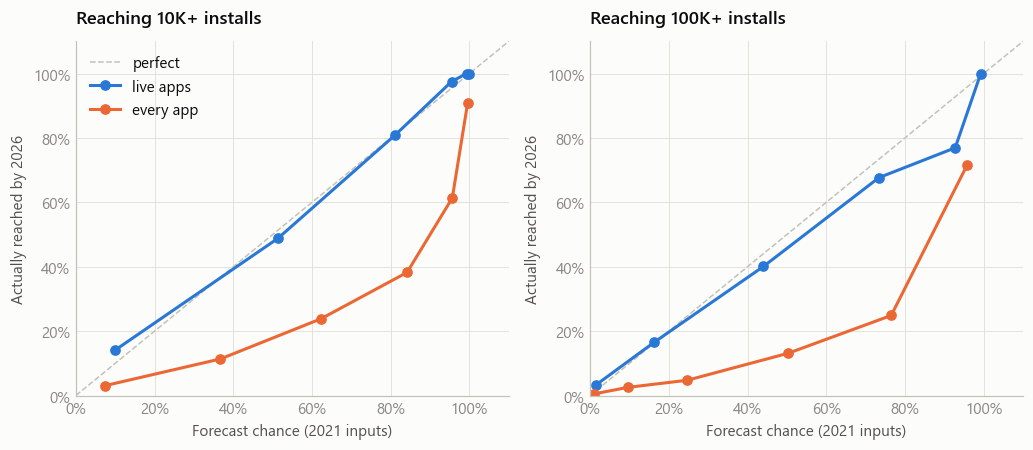

,forecast,actual,apps
model_10K+,,,
"(-0.0009080000000000001, 0.374]",10.0%,14.1%,240
"(0.374, 0.695]",51.3%,48.8%,239
"(0.695, 0.923]",81.1%,80.9%,239
"(0.923, 0.986]",95.5%,97.5%,239
"(0.986, 0.998]",99.3%,100.0%,239
"(0.998, 1.0]",99.9%,100.0%,239


In [7]:
def calibration(d, col, hit, n_bins=6):
    edges = np.unique(np.quantile(d[col], np.linspace(0, 1, n_bins + 1)))
    g = pd.cut(d[col], edges, include_lowest=True)
    return (d.assign(hit=hit.astype(float), w=d["weight"])
              .groupby(g, observed=True)
              .apply(lambda x: pd.Series({"forecast": np.average(x[col], weights=x["w"]),
                                          "actual": np.average(x["hit"], weights=x["w"]),
                                          "apps": len(x)}), include_groups=False))


fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
cal = {}
for ax, (t, k) in zip(axes, [("10K+", 2), ("100K+", 3)]):
    d = df[df["live"]]
    c = calibration(d, f"model_{t}", d["band_2026"] >= k)
    c_all = calibration(df, f"model_{t}", df["band_final"] >= k)
    cal[t], cal[t + " every app"] = c, c_all
    top = max(c["forecast"].max(), c["actual"].max(), c_all["actual"].max()) * 1.1
    ax.plot([0, top], [0, top], color=AXIS, lw=1, ls="--", label="perfect")
    ax.plot(c["forecast"], c["actual"], "o-", color=BLUE, label="live apps")
    ax.plot(c_all["forecast"], c_all["actual"], "o-", color=ORANGE, label="every app")
    ax.set_xlim(0, top)
    ax.set_ylim(0, top)
    ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set_xlabel("Forecast chance (2021 inputs)")
    ax.set_ylabel("Actually reached by 2026")
    ax.set_title(f"Reaching {t} installs")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()
cal["10K+"].style.format({"forecast": "{:.1%}", "actual": "{:.1%}", "apps": "{:.0f}"})

### 6 · Checked whether weak outlooks also predicted removal
Removed apps have no 2026 install count, so they were left out above. They still matter to a studio: an app pulled from the store is the worst outcome. Compared removal rates across apps grouped by their 2021 forecast chance of reaching 10K installs.

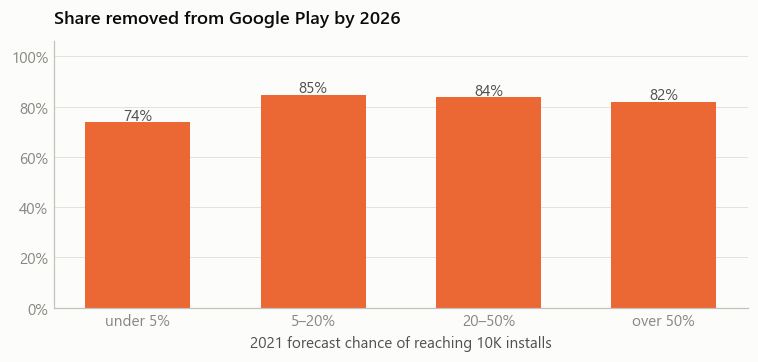

,forecast 10K+,removed by 2026,apps
outlook_group,,,
under 5%,1.5%,73.8%,346
5–20%,11.9%,84.8%,409
20–50%,34.4%,83.7%,864
over 50%,74.8%,82.0%,3381


In [8]:
df["outlook_group"] = pd.cut(df["model_10K+"], [0, 0.05, 0.2, 0.5, 1], include_lowest=True,
                             labels=["under 5%", "5–20%", "20–50%", "over 50%"])
removal = df.groupby("outlook_group", observed=True).apply(
    lambda x: pd.Series({"forecast 10K+": np.average(x["model_10K+"], weights=x["weight"]),
                         "removed by 2026": np.average(~x["live"], weights=x["weight"]),
                         "apps": len(x)}), include_groups=False)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(removal.index.astype(str), removal["removed by 2026"], color=ORANGE, width=0.6)
for i, v in enumerate(removal["removed by 2026"]):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center", color=INK_2)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0, removal["removed by 2026"].max() * 1.25)
ax.grid(axis="x", visible=False)
ax.set_xlabel("2021 forecast chance of reaching 10K installs")
ax.set_title("Share removed from Google Play by 2026")
plt.tight_layout()
plt.show()
removal.style.format({"forecast 10K+": "{:.1%}", "removed by 2026": "{:.1%}", "apps": "{:.0f}"})

### 7 · Saved the results for the app

In [9]:
u = df[df["live"] & df["unseen_dev"]].reset_index(drop=True)
ua = df[df["unseen_dev"]].reset_index(drop=True)
out = {
    "checked_from": f"{df['checked_at'].min():%Y-%m-%d}",
    "checked_to": f"{df['checked_at'].max():%Y-%m-%d}",
    "apps_checked": int(len(df)),
    "apps_unseen_dev": int(len(ua)),
    "apps_unseen_dev_live": int(len(u)),
    "removed_share": round(float(store_removed), 4),
    "moved_up_share": round(float(moved_up), 4),
    "model_live": {k: round(float(v), 4) for k, v in scores(u, "model").items()},
    "baseline_live": {k: round(float(v), 4) for k, v in scores(u, "base").items()},
    "model_every_app": {k: round(float(v), 4) for k, v in scores(ua, "model", "band_final").items()},
    "baseline_every_app": {k: round(float(v), 4) for k, v in scores(ua, "base", "band_final").items()},
    "calibration_10k_live": cal["10K+"][["forecast", "actual", "apps"]].round(4).values.tolist(),
    "calibration_10k_every_app": cal["10K+ every app"][["forecast", "actual", "apps"]].round(4).values.tolist(),
    "removal_by_outlook": removal["removed by 2026"].round(4).tolist(),
}
(ARTIFACTS / "out_of_time.json").write_text(json.dumps(out, indent=1), encoding="utf-8")
out

{'checked_from': '2026-10-06',
 'checked_to': '2026-10-06',
 'apps_checked': 5000,
 'apps_unseen_dev': 942,
 'apps_unseen_dev_live': 295,
 'removed_share': 0.8123,
 'moved_up_share': 0.5409,
 'model_live': {'accuracy': 0.4359,
  'within_one': 0.8667,
  'auc_10K+': 0.8614,
  'auc_100K+': 0.8661},
 'baseline_live': {'accuracy': 0.3729,
  'within_one': 0.6995,
  'auc_10K+': 0.562,
  'auc_100K+': 0.6491},
 'model_every_app': {'accuracy': 0.4575,
  'within_one': 0.8091,
  'auc_10K+': 0.8177,
  'auc_100K+': 0.8514},
 'baseline_every_app': {'accuracy': 0.5147,
  'within_one': 0.7933,
  'auc_10K+': 0.6185,
  'auc_100K+': 0.6722},
 'calibration_10k_live': [[0.0997, 0.1409, 240.0],
  [0.5133, 0.4879, 239.0],
  [0.8111, 0.8089, 239.0],
  [0.955, 0.9752, 239.0],
  [0.993, 1.0, 239.0],
  [0.9993, 1.0, 239.0]],
 'calibration_10k_every_app': [[0.0748, 0.0309, 834.0],
  [0.3675, 0.1137, 833.0],
  [0.6232, 0.2386, 833.0],
  [0.8417, 0.3824, 833.0],
  [0.9566, 0.6136, 833.0],
  [0.9956, 0.9089, 834.0]],

### Takeaways for the studio
- **The ranking held up five years out.** On developers the model never saw, it still placed an app that went on to pass 10K installs above one that didn't **86% of the time** (AUC 0.86, against 0.89 in the 2021 test), and 0.87 for 100K (against 0.93). Looking up the category alone managed 0.56, barely better than a coin toss. Comparing concepts against each other, which is how the Launch Outlook is used, still works on today's evidence.
- **For apps still on the store, the odds meant what they said.** Apps given about a 51% chance of reaching 10K got there 49% of the time, and apps given 81% got there 81% of the time.
- **Single-band calls got weaker over the longer horizon.** Exact band fell from 65% to 44%, while "within one band" stayed at 87%. Five extra years spread outcomes out, which is another reason the app shows odds and not one verdict.
- **The big miss was survival.** **81% of apps** that were 1–12 months old in June 2021 were gone from Google Play by October 2026, including 46% of apps that already had 1M+ installs. That scale is consistent with Google Play's well-reported clean-up of inactive and outdated apps in 2023–24. The 2021 outlook said nothing about which apps would be removed: removal ran at 74–85% across every forecast group. Counting removed apps as having stopped growing, apps given about a 62% chance of 10K reached it only 24% of the time.
- **What it means for Osu Lane Studio.** Read every Launch Outlook number as *"the odds if the app is still listed and maintained"*. Staying listed is a separate risk that launch-time choices don't capture. It comes down to upkeep (policy and Android-version updates, an active developer account), which matches notebook 04's finding that breakouts kept shipping updates. Concept B is still the recommendation, since the comparison between concepts is the part that held up best.

**Caveats:** only 295 apps from unseen developers were still live, so the ranges on those rows are wide (AUC 0.78–0.93). The "every app" scoring is a lower bound, because some removed apps grew before they were pulled.